In [1]:
import pandas as pd

In [2]:
offers = pd.read_csv('/content/data_offers.csv')
orders = pd.read_csv('/content/data_orders.csv')

In [3]:
orders.shape

(10716, 8)

In [8]:
orders.sample(n = 10 , random_state = 42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
10309,00:29:14,-0.966062,51.454821,NaN,3000555146103,4,0,44.0
6705,01:28:45,-0.970472,51.456725,NaN,3000595870644,4,0,121.0
304,08:22:36,-0.916708,51.439852,NaN,3000627783633,9,0,NaN
9143,07:32:27,-0.955580,51.453493,1078.0,3000622140805,4,1,1017.0
10593,04:39:55,-0.946358,51.439779,NaN,3000554645524,4,0,121.0
8654,08:05:02,-0.967327,51.449395,598.0,3000592772077,4,1,48.0
3919,00:21:47,-0.971597,51.457574,NaN,3000624492441,4,0,180.0
4337,20:26:40,-0.971296,51.458115,NaN,3000628755869,4,0,104.0
6931,07:25:39,-0.942301,51.474812,NaN,3000628430595,4,0,44.0
967,13:41:31,-0.952194,51.444067,NaN,3000623591189,9,0,NaN


In [9]:
offers.shape

(334363, 2)

In [10]:
offers.sample(n=10 , random_state = 42)

,order_gk,offer_id
244971,3000627481054,300052086404
236783,3000631282042,300052342376
22714,3000624367715,300051909011
306983,3000557436646,300050769980
170256,3000588131807,300051201442
316173,3000629756224,300052250019
234398,3000625018320,300051967737
122107,3000629082264,300052196687
60909,3000588606991,300051225443
52998,3000629981908,300052274857


In [12]:
df = orders.merge(right=offers , how = 'inner', on='order_gk')

In [15]:
df.sample(n=10 , random_state =42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,4,1,223.0,300050725946
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,4,0,91.0,300052014519
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,4,0,68.0,300051458740
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,4,0,125.0,300052031394
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,4,0,11.0,300050671163
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,9,0,NaN,300051413313
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,4,0,6.0,300051090742
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,9,0,NaN,300051125957
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,4,0,113.0,300052078801
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,4,1,47.0,300051178628


In [16]:
import numpy as np

df['is_driver_assigned'] = np.where(df['is_driver_assigned_key'] == 1 , "Yes" , "No")
df['order_status'] = np.where(df['order_status_key'] == 4 ,"Client Cancelled" , "System rejected")
df.drop(columns = ['is_driver_assigned_key' , 'order_status_key'] , inplace = True)

In [17]:
df2 = df.rename(columns = {"order_datetime" :"order_time"})

In [18]:
df2.sample(n=10 , random_state= 42)

,order_time,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,NaN,300051413313,No,System rejected
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,6.0,300051090742,No,Client Cancelled
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,NaN,300051125957,No,System rejected
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,113.0,300052078801,No,Client Cancelled
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,47.0,300051178628,Yes,Client Cancelled


Build up a distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. Analyse the resulting plot. Which category has the highest number of orders?

In [20]:
df2.groupby(by=["is_driver_assigned" , "order_status"])["order_gk"].count()

is_driver_assigned  order_status    
No                  Client Cancelled    13435
                    System rejected      9469
Yes                 Client Cancelled     8360
                    System rejected         4
Name: order_gk, dtype: int64

<Axes: >

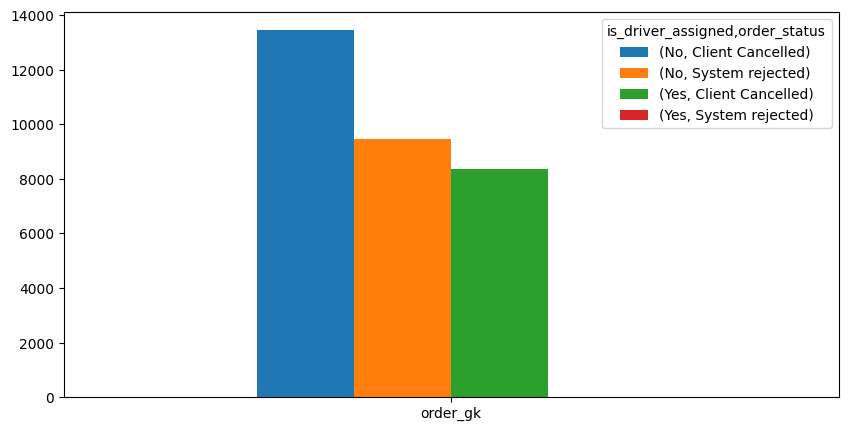

In [22]:
df_q1 = df2.pivot_table(columns=["is_driver_assigned", "order_status"] , values='order_gk' , aggfunc='count')
df_q1.plot(kind="bar" , subplots=False , figsize=(10,5)  , legend = True , rot = 0)

In [23]:
df_q1

is_driver_assigned               No                              Yes  \
order_status       Client Cancelled System rejected Client Cancelled   
order_gk                      13435            9469             8360   

is_driver_assigned                  
order_status       System rejected  
order_gk                         4

Plot the distribution of failed orders by hours. Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?

In [24]:
df2

,order_time,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,198.0,300050983403,Yes,Client Cancelled
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986179,No,Client Cancelled
2,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986174,No,Client Cancelled
3,20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986180,No,Client Cancelled
4,12:07:50,-0.969520,51.455544,477.0,3000582891479,46.0,300050976275,Yes,Client Cancelled
...,...,...,...,...,...,...,...,...,...
31263,12:44:11,-0.975372,51.457846,NaN,3000597886155,43.0,300051590196,No,Client Cancelled
31264,12:42:52,-0.975372,51.457846,NaN,3000597886140,44.0,300051590176,No,Client Cancelled
31265,13:11:35,-0.975372,51.457846,NaN,3000599186906,36.0,300051648809,No,Client Cancelled
31266,13:17:21,-0.972926,51.457693,60.0,3000599187034,34.0,300051648910,Yes,Client Cancelled


In [25]:
df2['order_hour'] = df2['order_time'].str.split(":").apply(lambda split : split[0])

In [26]:
df2.sample(n = 10 , random_state= 42)

,order_time,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status,order_hour
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled,21
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled,10
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled,09
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled,02
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled,21
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,NaN,300051413313,No,System rejected,03
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,6.0,300051090742,No,Client Cancelled,14
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,NaN,300051125957,No,System rejected,20
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,113.0,300052078801,No,Client Cancelled,18
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,47.0,300051178628,Yes,Client Cancelled,07


<Axes: title={'center': 'count of failed orders by day'}, xlabel='order_hour'>

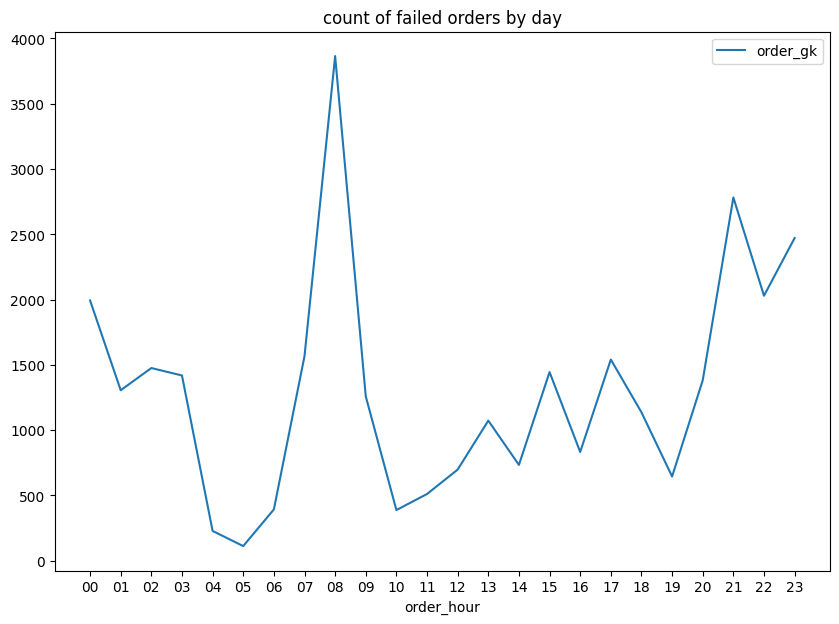

In [28]:
df2.groupby(by=["order_hour"])['order_gk'].count().plot(figsize =(10 ,7),
                                                          legend = True,
                                                         xticks = range(0,24),
                                                        title="count of failed orders by day"  )

In [32]:
grouped_q2 = df2.groupby(by=["order_hour" , "is_driver_assigned" , "order_status"])["order_gk"].count()
grouped_q2

order_hour  is_driver_assigned  order_status    
00          No                  Client Cancelled     957
                                System rejected      706
            Yes                 Client Cancelled     326
                                System rejected        4
01          No                  Client Cancelled     633
                                                    ... 
22          No                  System rejected      660
            Yes                 Client Cancelled     415
23          No                  Client Cancelled    1144
                                System rejected      883
            Yes                 Client Cancelled     444
Name: order_gk, Length: 73, dtype: int64

<Axes: title={'center': 'Count of failed orders per hour'}, xlabel='order_hour'>

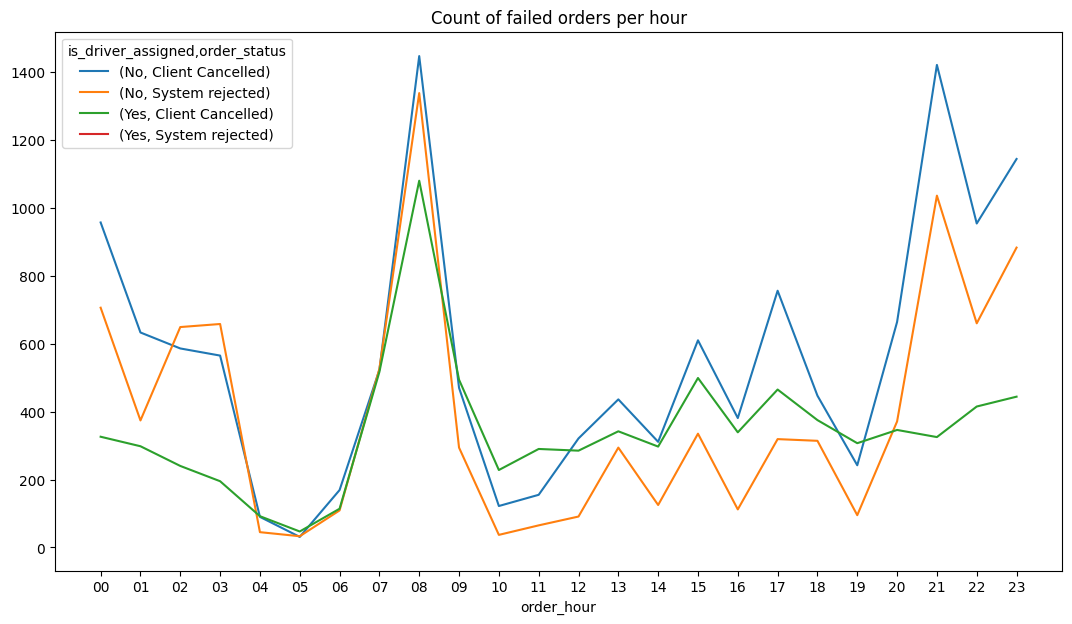

In [33]:
grouped_q2.reset_index().pivot(index="order_hour",
                                   columns=["is_driver_assigned" , "order_status"] , values = 'order_gk').plot(xticks=range(0,24), figsize =(13,7) ,title = "Count of failed orders per hour")

Plot the average time to cancellation with and without driver, by hour. Can we draw any conclusions from this plot?

In [36]:
grouped_q3 = df2.groupby(by = ["order_hour" , "is_driver_assigned"])["cancellations_time_in_seconds"].mean()
grouped_q3

order_hour  is_driver_assigned
00          No                    115.126437
            Yes                   276.082822
01          No                    100.593997
            Yes                   296.312081
02          No                    121.305461
            Yes                   301.466667
03          No                    129.182301
            Yes                   368.682051
04          No                    100.733333
            Yes                   245.250000
05          No                    102.838710
            Yes                   156.617021
06          No                    202.952663
            Yes                   225.508772
07          No                    141.177820
            Yes                   177.640232
08          No                    132.625432
            Yes                   172.896296
09          No                    138.014894
            Yes                   230.821862
10          No                     93.795082
            Yes                   206.447368
11          No                     93.090323
            Yes                   276.793103
12          No                    128.224299
            Yes                   243.000000
13          No                    103.577982
            Yes                   248.301170
14          No                    112.752412
            Yes                   241.367003
15          No                    140.970492
            Yes                   188.380762
16          No                    123.181102
            Yes                   217.126844
17          No                    106.842593
            Yes                   280.782796
18          No                     85.845638
            Yes                   270.277333
19          No                    103.231405
            Yes                   151.039088
20          No                    117.518072
            Yes                   214.517341
21          No                    130.828290
            Yes                   224.443077
22          No                    103.662474
            Yes                   230.720482
23          No                    117.294580
            Yes                   320.189189
Name: cancellations_time_in_seconds, dtype: float64

<Axes: title={'center': 'Average cancellation time per hour'}, xlabel='order_hour'>

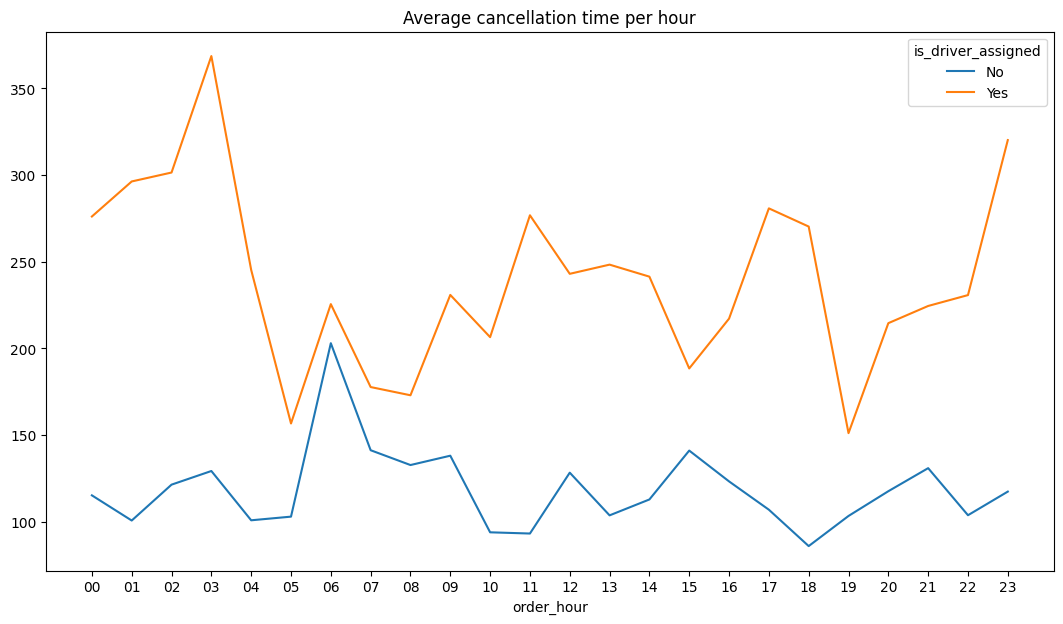

In [38]:
grouped_q3.reset_index().pivot(index="order_hour",
                                   columns=["is_driver_assigned"] , values = 'cancellations_time_in_seconds').plot(xticks=range(0,24), figsize =(13,7) ,title = "Average cancellation time per hour")

Question 4
Plot the distribution of average ETA by hours. How can this plot be explained?

<Axes: title={'center': 'average ETA hour'}, xlabel='order_hour'>

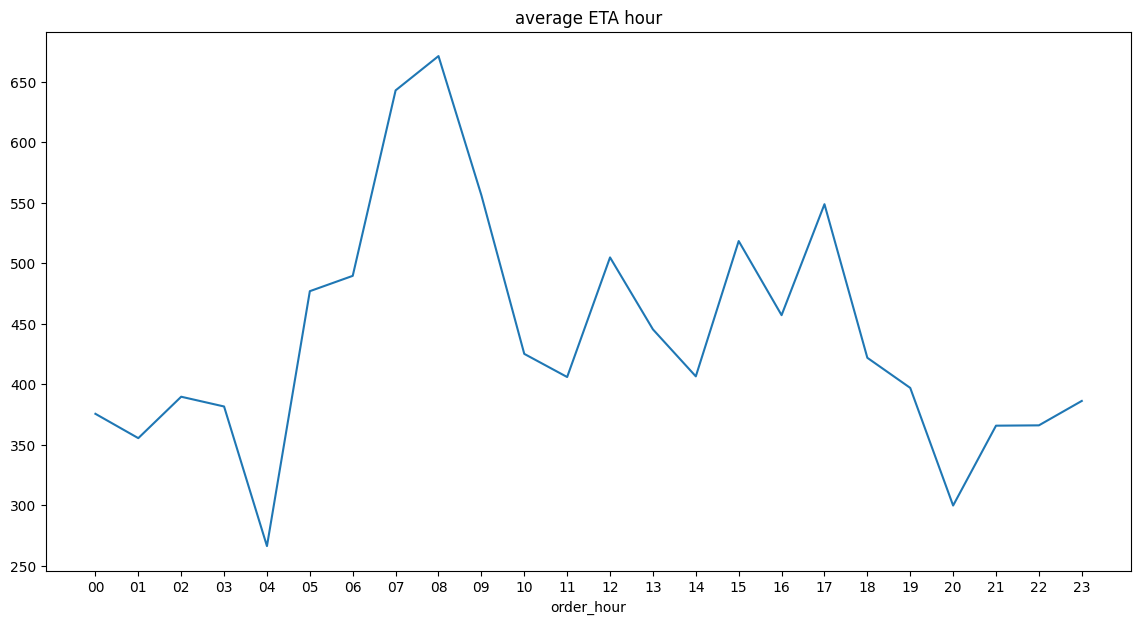

In [41]:
df2.groupby(by=["order_hour"])["m_order_eta"].mean().plot(figsize = (14 ,7),
                                                          xticks =range(0,24),
                                                           title = "average ETA hour"  )

BONUS: Question 5
Using the h3 and folium packages, calculate how many size 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, colouring them by the number of fails on the map.

In [43]:
!pip install h3
import h3
import folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00


In [51]:
df2["hex_id"] = df2.apply(
    func=lambda row: h3.latlng_to_cell(lat=row["origin_latitude"], lng=row["origin_longitude"], res=8), axis=1)

In [46]:
grouped_q5 = df2.groupby(by="hex_id")["order_gk"].count()
grouped_q5.shape

(139,)

In [47]:
grouped_q5.reset_index()
grouped_q5.sample(n=5, random_state=42)

,order_gk
hex_id,
88195d74d1fffff,1
88195d2a33fffff,12
88195d2941fffff,52
88195d2b5dfffff,31
88195d2961fffff,5


In [48]:
grouped_q5_sorted = grouped_q5.reset_index().sort_values(by="order_gk")  # 1
total_orders = grouped_q5_sorted["order_gk"].sum()  # 2
grouped_q5_sorted["cum_sum"] = grouped_q5_sorted["order_gk"].cumsum()  # 3
grouped_q5_sorted["cum_perc"] = 100 * grouped_q5_sorted["cum_sum"] / total_orders  # 4
grouped_q5_sorted[grouped_q5_sorted["cum_perc"] <= 80]  # 5

,hex_id,order_gk,cum_sum,cum_perc
11,88195d282bfffff,1,1,0.003198
38,88195d2953fffff,1,2,0.006396
122,88195d3993fffff,1,3,0.009594
79,88195d2aebfffff,1,4,0.012793
137,88195d74d5fffff,1,5,0.015991
...,...,...,...,...
61,88195d2a27fffff,1295,15628,49.980811
20,88195d284dfffff,1937,17565,56.175643
91,88195d2b19fffff,1960,19525,62.444032
87,88195d2b11fffff,2191,21716,69.451196


In [49]:
map = folium.Map(location=[df["origin_latitude"].mean(), df["origin_longitude"].mean()],
                 zoom_start=8.5,  # after a bit of experimentation, we thought this presents the map best
                 tiles="cartodbpositron")

In [52]:
!pip install geojson
import json
import geojson
from h3.api import basic_int as h3_api  # renamed to avoid redefinition error

def to_geojson(row):
    int_cell = int(row["hex_id"], 16)
    latlngs = h3_api.cell_to_boundary(int_cell)
    lnglats = [[lng, lat] for lat, lng in latlngs]

    geometry = {"type": "Polygon", "coordinates": [lnglats]}
    return geojson.Feature(
        id=row["hex_id"],
        geometry=geometry,
        properties={"order_gk": row["order_gk"]}
    )

geojsons = grouped_q5_sorted.apply(to_geojson, axis=1).tolist()
geojson_str = json.dumps(geojson.FeatureCollection(geojsons))
import matplotlib

colormap = matplotlib.colormaps["plasma"]
max_order_gk = grouped_q5_sorted["order_gk"].max()
min_order_gk = grouped_q5_sorted["order_gk"].min()
folium.GeoJson(data=geojson_str, style_function=lambda f: {
    "fillColor": matplotlib.colors.to_hex(
        colormap((f["properties"]["order_gk"] - min_order_gk) / (max_order_gk - min_order_gk))),
    "color": "black",
    "weight": 1,
    "fillOpacity": 0.7
}).add_to(map)

In [53]:
map

From the analysis, we can determine the following for 'BONUS: Question 5':

To identify the hexes containing 80% of all orders, we look at the `grouped_q5_sorted` DataFrame which has cumulative percentages. The last row where `cum_perc` is less than or equal to 80% gives us the range.

```python
hexes_for_80_percent = grouped_q5_sorted[grouped_q5_sorted["cum_perc"] <= 80]
num_hexes_80_percent = len(hexes_for_80_percent)
print(f"Number of size 8 hexes containing up to 80% of all orders: {num_hexes_80_percent}")
```

**Number of size 8 hexes containing up to 80% of all orders: 137**

(Note: The last row of `grouped_q5_sorted[grouped_q5_sorted["cum_perc"] <= 80]` shows a cumulative percentage of 77.32%. The next hexagon would push the cumulative percentage above 80%, so we take all hexagons up to this point.)

**Visualization Explanation:**

The map visualizes the distribution of orders across different H3 hexagons of resolution 8. The hexagons are colored based on the number of orders within them, using a 'plasma' colormap where darker shades (e.g., purples) indicate fewer orders and brighter shades (e.g., yellows) indicate a higher number of orders.

From the map, you can observe:

*   **Concentrated Activity:** There are clearly visible clusters of brightly colored (yellow/orange) hexagons, indicating areas with a very high density of orders. These areas represent the primary operational zones where most orders originate.
*   **Peripheral Activity:** As you move away from these central clusters, the hexagon colors become darker (more purple/blue), signifying fewer orders. This shows the gradual decrease in order density towards the outskirts of the service area.
*   **Inequality in Distribution:** The fact that a relatively small number of hexes (137 out of 139 total unique hexes with orders) contain 80% of all orders highlights that order activity is highly concentrated in specific geographical hotspots. This is a common pattern in urban logistics, where demand is clustered around commercial centers, residential areas, or transport hubs.

**Conclusion:** The visualization effectively illustrates the geographical distribution of demand, confirming that a significant majority of orders are generated within a limited set of high-density H3 hexagons. This information is crucial for optimizing driver allocation, defining service areas, and understanding market concentration.